In [5]:
from cytetype import CyteType
import scanpy as sc

In [19]:
adata = sc.read_h5ad('../../data/talbot_xenium_tumor.h5ad')

In [20]:
adata.obs.genotype

output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaachibf-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaadbpmc-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagejpm-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagiphc-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaahpgfk-1      Pdl1_wt
                                                                      ...   
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oikfjlfk-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilbhfce-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilfjaec-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilfkjkg-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilnplad-1    Pdl1_cre
Name: genotype, Length: 207468, dtype: category
Categories (5, object): ['Oprl1_cre', 'Oprl1_wt', 'Pdl1_cre', 'Pdl1_wt', 'c57']

## Q6: Metadata audit
Check all obs columns for unexpected variables 

In [21]:
# Q6: Inspect all obs columns — flag any unexpected ones (e.g., 'age')
print("All obs columns:")
for col in adata.obs.columns:
    print(f"  {col}: dtype={adata.obs[col].dtype}, n_unique={adata.obs[col].nunique()}")

unexpected = [c for c in adata.obs.columns
              if c.lower() in ('age', 'mouse_age', 'donor_age')]
if unexpected:
    print(f"\n⚠️  Unexpected column(s) found: {unexpected}")
    print("Sample values:", {c: adata.obs[c].unique()[:5].tolist() for c in unexpected})
    print("Dropping these columns (not part of the Talbot dataset).")
    adata.obs.drop(columns=unexpected, inplace=True)
else:
    print("\n✓ No unexpected 'age'-related columns found.")

All obs columns:
  x_centroid: dtype=float64, n_unique=206308
  y_centroid: dtype=float64, n_unique=206386
  transcript_counts: dtype=int64, n_unique=4396
  control_probe_counts: dtype=int64, n_unique=4
  genomic_control_counts: dtype=int64, n_unique=4
  control_codeword_counts: dtype=int64, n_unique=4
  unassigned_codeword_counts: dtype=int64, n_unique=12
  deprecated_codeword_counts: dtype=int64, n_unique=7
  total_counts: dtype=float32, n_unique=4396
  cell_area: dtype=float64, n_unique=7198
  nucleus_area: dtype=float64, n_unique=3906
  nucleus_count: dtype=int64, n_unique=8
  segmentation_method: dtype=category, n_unique=3
  run: dtype=category, n_unique=1
  sample_folder: dtype=category, n_unique=5
  sample___: dtype=category, n_unique=5
  condition: dtype=category, n_unique=5
  tissue: dtype=category, n_unique=1
  genotype: dtype=category, n_unique=5
  timepoint: dtype=category, n_unique=0
  seg_method_short: dtype=category, n_unique=3
  n_genes_by_counts: dtype=int32, n_unique=

In [22]:
adata.var = adata.var.reset_index()

/Users/christoffer/miniconda3/envs/cellcharter-env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [23]:
adata.var['gene_symbols'] = adata.var['index']

In [24]:
adata.var['gene_symbols']

0         A1cf
1          A2m
2         Aatf
3        Abca1
4       Abca13
         ...  
5001    Zswim9
5002      Zup1
5003       Zyx
5004     Zzef1
5005         a
Name: gene_symbols, Length: 5006, dtype: object

In [25]:
adata.var = adata.var.set_index('index')

In [26]:
study_context = (
    "Mouse melanoma tissue profiled with the Xenium platform to resolve the spatial organization of tumor, stromal, "
    "and immune cell populations. The dataset includes multiple genotypes—Oprl1_cre, Oprl1_wt, Pdl1_cre, Pdl1_wt, "
    "and C57—representing genetic backgrounds relevant to immune checkpoint regulation and tumor–immune interactions. "
    "This study enables spatially resolved analysis of gene expression, cell–cell communication, and microenvironmental "
    "differences across melanoma genotypes. We should expect some B and T cells as well."
)

In [27]:
# ------ CyteType ------
annotator = CyteType(adata, group_key="leiden_4")
adata = annotator.run(
    study_context=study_context,
)


Using coordinates from 'X_umap' for visualization.
Calculating expression percentages...
Extracting marker genes...
Aggregating cluster metadata...
Extracting sampled visualization coordinates...
Sampled 1000 cells from group '3' (originally 7946 cells)
Sampled 1000 cells from group '40' (originally 2037 cells)
Sampled 1000 cells from group '38' (originally 2061 cells)
Sampled 1000 cells from group '26' (originally 2624 cells)
Sampled 1000 cells from group '13' (originally 5087 cells)
Sampled 1000 cells from group '47' (originally 1697 cells)
Sampled 1000 cells from group '11' (originally 5170 cells)
Sampled 1000 cells from group '2' (originally 7960 cells)
Sampled 1000 cells from group '31' (originally 2324 cells)
Sampled 1000 cells from group '23' (originally 3866 cells)
Sampled 1000 cells from group '51' (originally 1386 cells)
Sampled 1000 cells from group '45' (originally 1755 cells)
Sampled 1000 cells from group '49' (originally 1668 cells)
Sampled 1000 cells from group '41' (ori

In [29]:
adata.obs['cytetype_annotation_leiden_4'].unique()

['Stress-responsive differentiating suprabasal ..., 'Stress-adapted basal keratinocyte', 'Tumor-associated hair follicle-reprogrammed b..., 'Sebaceous gland progenitor', 'Differentiating suprabasal keratinocyte', ..., 'Hypoxic melanoma cell', 'Invasive ECM-remodeling melanoma', 'Proliferating melanoma cell', 'Hypoxic-proliferative melanoma cell', 'Melanoma cell - interferon-responsive']
Length: 66
Categories (66, object): ['APP-high CAF', 'Angiogenic blood endothelial cell', 'Basal keratinocyte', 'Basal keratinocyte with immune-like features', ..., 'Tumor-associated lymphatic endothelial cell', 'Tumor-inflamed lymphatic endothelial cell', 'WNT-active stem-like melanoma', 'Wnt-responsive CAF']

## Q1: Immune compartment — panel coverage + annotation survey

**Step 1:** Check which immune/Schwann cell marker genes are actually present in the Xenium panel.  
**Step 2:** Survey which immune cell types CyteType detected in the annotations.

If key marker genes (e.g. Cd3e for T cells, Cd19/Cd79a for B cells, Mbp/Sox10 for Schwann cells) are absent from the panel, CyteType cannot reliably detect those populations — and re-running with a different context will not help. In that case, those cell types would need to be noted as outside the panel's resolution.

In [30]:
adata.write('../../data/talbot_xenium_tumor_annotated_updated.h5ad')

In [ ]:
adata = sc.read_h5ad('../../data/talbot_xenium_tumor_annotated_updated.h5ad')

=== Immune / Schwann marker genes in Xenium panel ===

✓ T cell           present : ['Cd3e', 'Cd3d', 'Cd3g', 'Cd4', 'Cd8a', 'Cd8b1', 'Foxp3']
                   absent  : ['Trac', 'Trbc1']
✓ B cell           present : ['Cd19', 'Cd79a', 'Cd79b', 'Ms4a1', 'Pax5', 'Ighm', 'Cd22']
✓ NK cell          present : ['Klrb1c', 'Ncr1', 'Gzmb', 'Klrd1', 'Prf1']
                   absent  : ['Nkg7']
✓ Macrophage       present : ['Csf1r', 'Adgre1', 'Cd68', 'Mrc1', 'Trem2']
                   absent  : ['C1qb', 'C1qa']
✓ Dendritic        present : ['Itgax', 'Flt3', 'Xcr1', 'Ccr7', 'Clec9a']
                   absent  : ['Siglech']
✓ Mast cell        present : ['Kit', 'Tpsab1', 'Hdc']
                   absent  : ['Fcer1a', 'Cpa3']
✓ Schwann cell     present : ['S100b', 'Sox10', 'Ngfr', 'Ncam1']
                   absent  : ['Mbp', 'Mpz', 'Plp1']
✓ Neutrophil       present : ['Cxcr2', 'Ly6g', 'Csf3r']
                   absent  : ['S100a8', 'S100a9']

→ Cell types with NO panel markers cannot be resolv

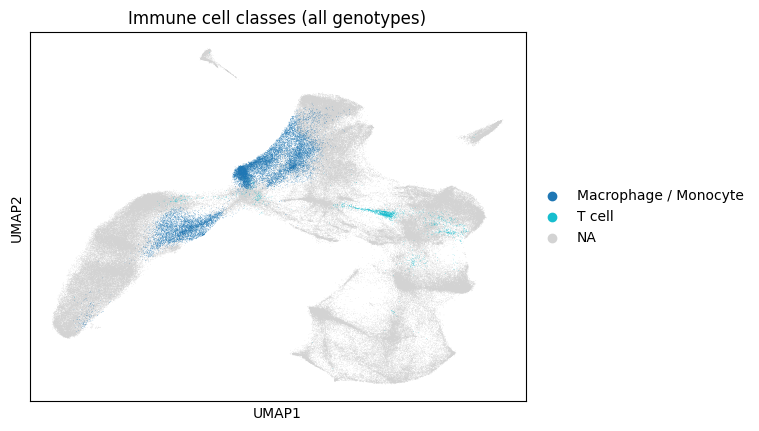

In [31]:
import numpy as np

# ── Step 1: Which immune/Schwann marker genes are in the Xenium panel? ──────
immune_markers = {
    'T cell':        ['Cd3e', 'Cd3d', 'Cd3g', 'Cd4', 'Cd8a', 'Cd8b1', 'Foxp3', 'Trac', 'Trbc1'],
    'B cell':        ['Cd19', 'Cd79a', 'Cd79b', 'Ms4a1', 'Pax5', 'Ighm', 'Cd22'],
    'NK cell':       ['Nkg7', 'Klrb1c', 'Ncr1', 'Gzmb', 'Klrd1', 'Prf1'],
    'Macrophage':    ['Csf1r', 'Adgre1', 'Cd68', 'Mrc1', 'Trem2', 'C1qb', 'C1qa'],
    'Dendritic':     ['Itgax', 'Flt3', 'Xcr1', 'Siglech', 'Ccr7', 'Clec9a'],
    'Mast cell':     ['Kit', 'Fcer1a', 'Cpa3', 'Tpsab1', 'Hdc'],
    'Schwann cell':  ['Mbp', 'Mpz', 'Plp1', 'S100b', 'Sox10', 'Ngfr', 'Ncam1'],
    'Neutrophil':    ['S100a8', 'S100a9', 'Cxcr2', 'Ly6g', 'Csf3r'],
}

panel_genes = set(adata.var_names)
print("=== Immune / Schwann marker genes in Xenium panel ===\n")
panel_coverage = {}
for cell_type, markers in immune_markers.items():
    found   = [g for g in markers if g in panel_genes]
    missing = [g for g in markers if g not in panel_genes]
    status  = "✓" if found else "✗"
    panel_coverage[cell_type] = found
    print(f"{status} {cell_type:<16} present : {found}")
    if missing:
        print(f"  {'':16} absent  : {missing}")

print("\n→ Cell types with NO panel markers cannot be resolved by CyteType.")

# ── Step 2: Survey CyteType annotation results ───────────────────────────────
annot_col = 'cytetype_annotation_leiden_4'
all_celltypes = adata.obs[annot_col].cat.categories.tolist()

immune_keywords = [
    't cell', 't-cell', 'b cell', 'b-cell', 'nk cell', 'nk-cell',
    'dendritic', 'mast', 'schwann', 'macrophage', 'monocyte',
    'neutrophil', 'lymphocyte', 'plasma cell', 'plasmablast',
    'regulatory t', 'treg', 'cd4', 'cd8', 'natural killer',
]

immune_types = [
    (ct, int((adata.obs[annot_col] == ct).sum()))
    for ct in all_celltypes
    if any(kw in ct.lower() for kw in immune_keywords)
]

print(f"\n=== Immune-related CyteType annotations ({len(immune_types)} types) ===\n")
for ct, n in sorted(immune_types, key=lambda x: -x[1]):
    print(f"  {n:>8,}  {ct}")

# ── Step 3: Build immune_class column ────────────────────────────────────────
def classify_immune(name):
    n = name.lower()
    if any(k in n for k in ['t cell', 't-cell', 'cd4', 'cd8', 'regulatory t', 'treg']): return 'T cell'
    if any(k in n for k in ['b cell', 'b-cell', 'plasma cell', 'plasmablast']):          return 'B / Plasma cell'
    if any(k in n for k in ['nk cell', 'natural killer']):                               return 'NK cell'
    if any(k in n for k in ['macrophage', 'monocyte']):                                  return 'Macrophage / Monocyte'
    if 'dendritic' in n:                                                                  return 'Dendritic cell'
    if 'mast' in n:                                                                       return 'Mast cell'
    if 'schwann' in n:                                                                    return 'Schwann cell'
    if 'neutrophil' in n:                                                                 return 'Neutrophil'
    if 'lymphocyte' in n:                                                                 return 'Lymphocyte (other)'
    return None

adata.obs['immune_class'] = adata.obs[annot_col].map(classify_immune)
print("\n=== Cells per immune class ===")
print(adata.obs['immune_class'].value_counts(dropna=False).to_string())

# ── Step 4: UMAP — immune classes highlighted, rest greyed out ───────────────
sc.pl.umap(adata, color='immune_class', title='Immune cell classes (all genotypes)',
           na_color='lightgrey', palette='tab10')

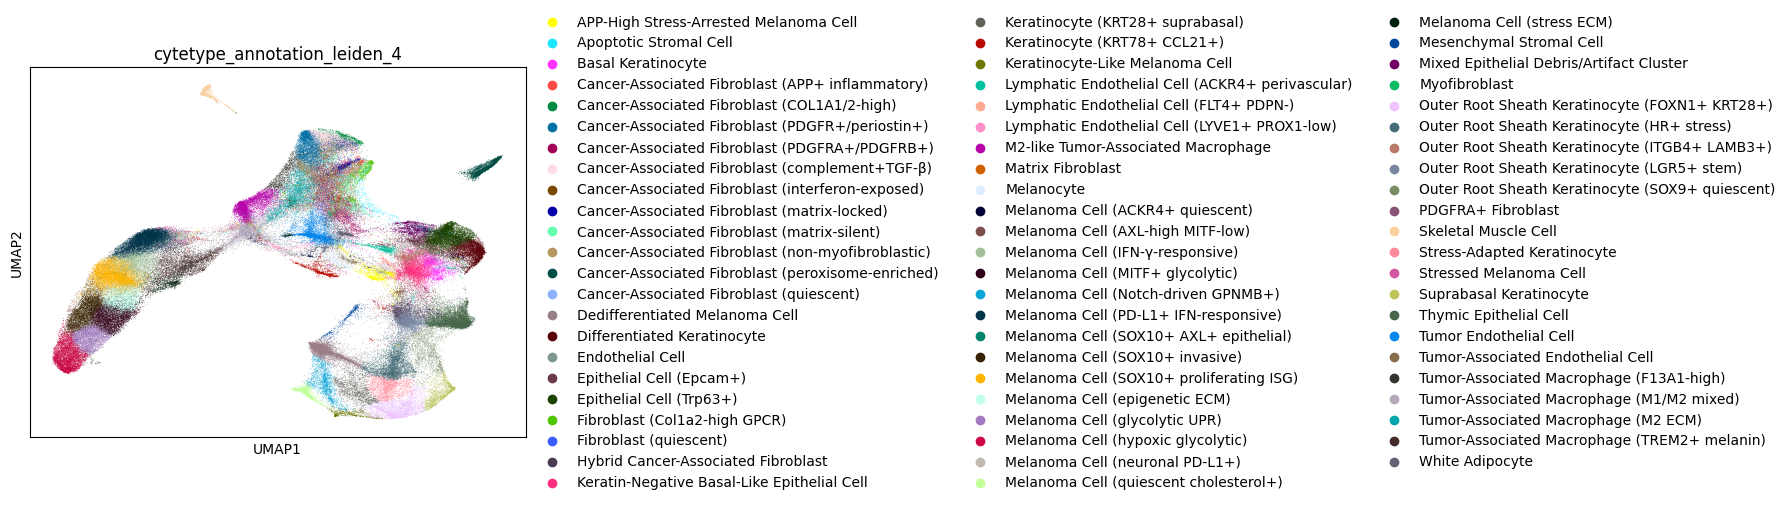

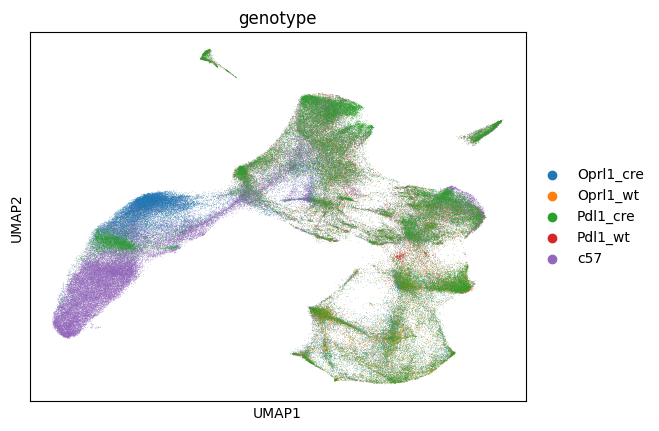

In [20]:
sc.pl.umap(adata, color = 'cytetype_annotation_leiden_4')
sc.pl.umap(adata, color = 'genotype')

## UMAP split by genotype group (Q2 & Q5)
**Group 1:** Oprl1_cre, Oprl1_wt, C57  
**Group 2:** Pdl1_cre, Pdl1_wt, C57

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# ── Q5: CyteType confidence score range ──────────────────────────────────────
# CyteType scores range 0–1 (1 = highest annotation confidence).
# Each score is assigned per Leiden cluster; all cells in a cluster share the same score.

if 'cytetype_results' in adata.uns:
    results = adata.uns['cytetype_results']
    # Build a per-cluster score table
    score_rows = []
    for grp, data in results.items():
        if isinstance(data, dict):
            score = data.get('score', data.get('confidence', None))
            label = data.get('cell_type', data.get('annotation', ''))
            if score is not None:
                score_rows.append({'leiden_4': str(grp), 'score': float(score), 'label': label})

    if score_rows:
        score_df = pd.DataFrame(score_rows)
        print(f"CyteType score range:  min={score_df.score.min():.3f}  "
              f"max={score_df.score.max():.3f}  mean={score_df.score.mean():.3f}")
        print(f"(Scores are per-cluster, not per-cell. Max possible value is 1.0.)\n")

        # Map cluster scores back to cells
        adata.obs['cytetype_score'] = (
            adata.obs['leiden_4']
                 .map(score_df.set_index('leiden_4')['score'])
                 .astype(float)
        )

        # ── Q5: Split score UMAP by genotype group ───────────────────────────
        GROUP1 = ['Oprl1_cre', 'Oprl1_wt', 'c57']
        GROUP2 = ['Pdl1_cre', 'Pdl1_wt', 'c57']

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for ax, (title, group) in zip(axes, [
            ('Group 1: Oprl1_cre, Oprl1_wt, C57', GROUP1),
            ('Group 2: Pdl1_cre, Pdl1_wt, C57',   GROUP2),
        ]):
            sub = adata[adata.obs['genotype'].isin(group)]
            sc.pl.umap(sub, color='cytetype_score', title=title,
                       vmin=0, vmax=1, color_map='viridis',
                       show=False, ax=ax)
        plt.tight_layout()
        plt.show()

        # ── Q5: Score distribution per genotype ──────────────────────────────
        plot_df = adata.obs[['genotype', 'cytetype_score']].dropna()
        order = ['Oprl1_cre', 'Oprl1_wt', 'c57', 'Pdl1_cre', 'Pdl1_wt']
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.boxplot(data=plot_df, x='genotype', y='cytetype_score', order=order,
                    palette='Set2', ax=ax)
        ax.set_title('CyteType confidence score by genotype')
        ax.set_xlabel('')
        ax.set_ylabel('Score (0–1)')
        ax.axvline(2.5, color='grey', linestyle='--', linewidth=0.8)
        plt.tight_layout()
        plt.show()
    else:
        print("Score field not found in cytetype_results — check adata.uns['cytetype_results'] structure.")
        first_key = next(iter(results))
        print(f"Keys in first entry: {list(results[first_key].keys()) if isinstance(results[first_key], dict) else type(results[first_key])}")
else:
    print("cytetype_results not found in adata.uns")

Score field not found in cytetype_results — check adata.uns['cytetype_results'] structure.
Keys in first entry: <class 'str'>


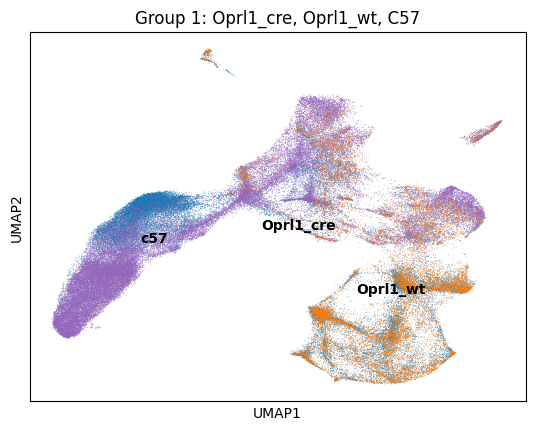

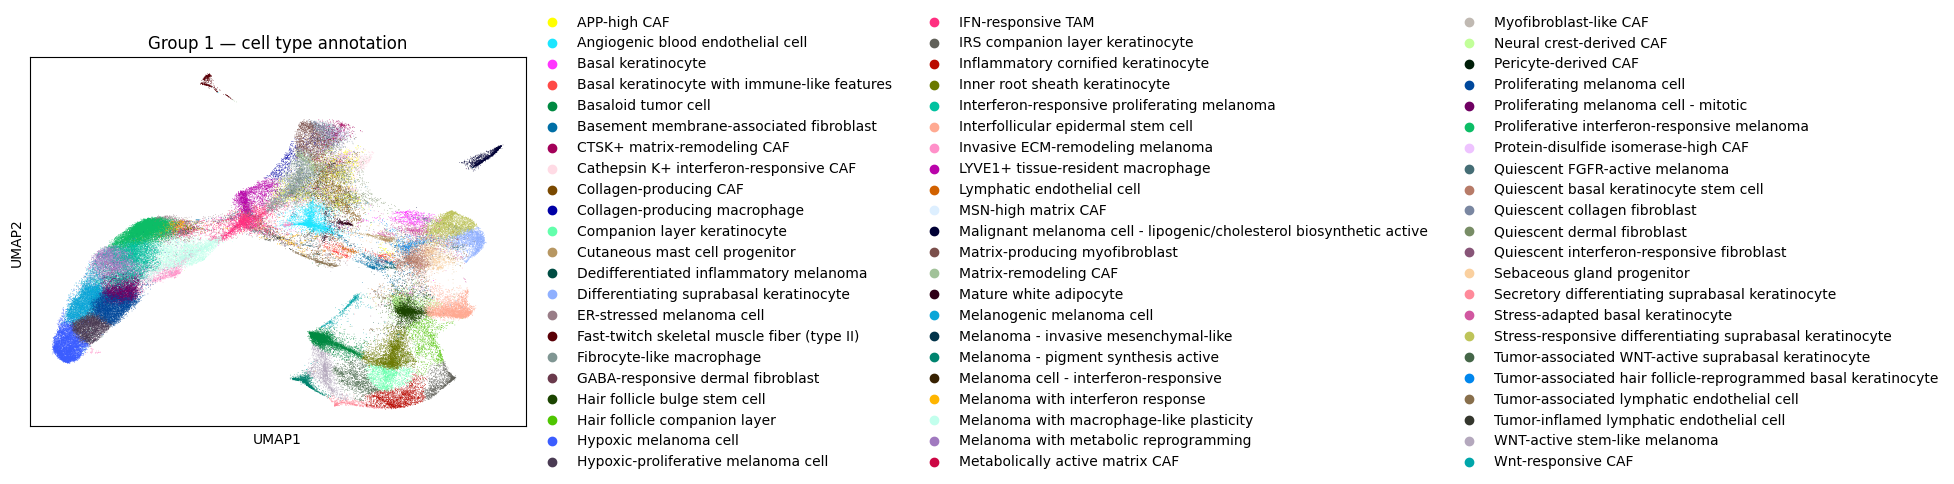

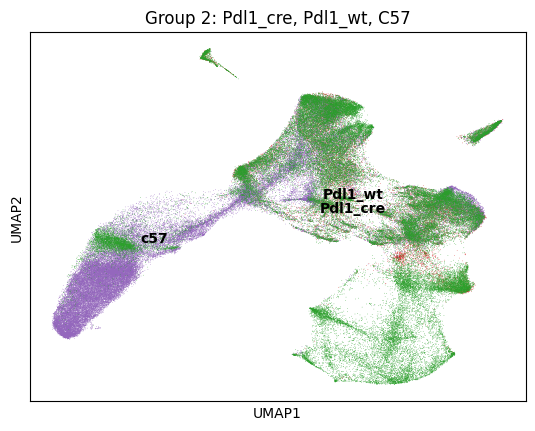

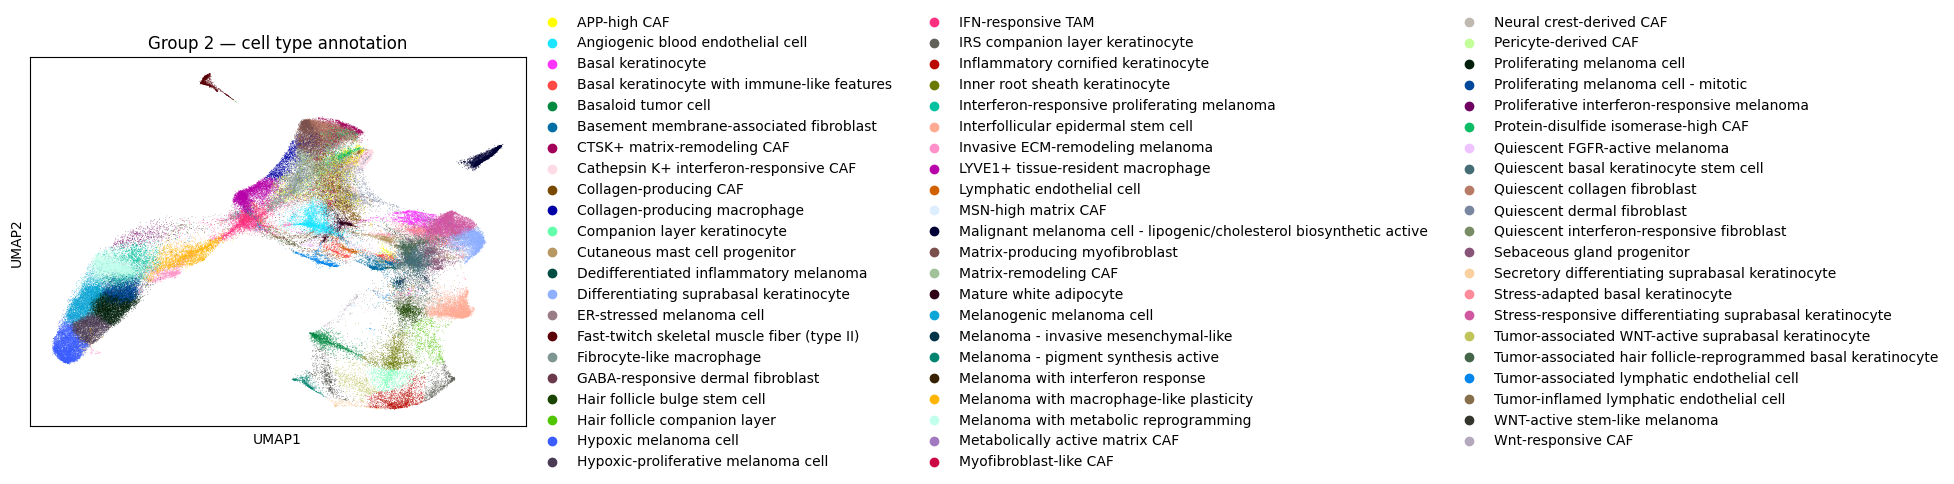

In [33]:
# Q2 & Q5: Split UMAP/UMAP plots by genotype group
GROUP1 = ['Oprl1_cre', 'Oprl1_wt', 'c57']
GROUP2 = ['Pdl1_cre', 'Pdl1_wt', 'c57']

adata_g1 = adata[adata.obs['genotype'].isin(GROUP1)].copy()
adata_g2 = adata[adata.obs['genotype'].isin(GROUP2)].copy()

# --- Group 1 ---
sc.pl.umap(adata_g1, color='genotype',
           title='Group 1: Oprl1_cre, Oprl1_wt, C57', legend_loc='on data')
sc.pl.umap(adata_g1, color='cytetype_annotation_leiden_4',
           title='Group 1 — cell type annotation', legend_loc='right margin')

# --- Group 2 ---
sc.pl.umap(adata_g2, color='genotype',
           title='Group 2: Pdl1_cre, Pdl1_wt, C57', legend_loc='on data')
sc.pl.umap(adata_g2, color='cytetype_annotation_leiden_4',
           title='Group 2 — cell type annotation', legend_loc='right margin')


In [35]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=6, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

Plotting cytetype_annotation_leiden_4 …


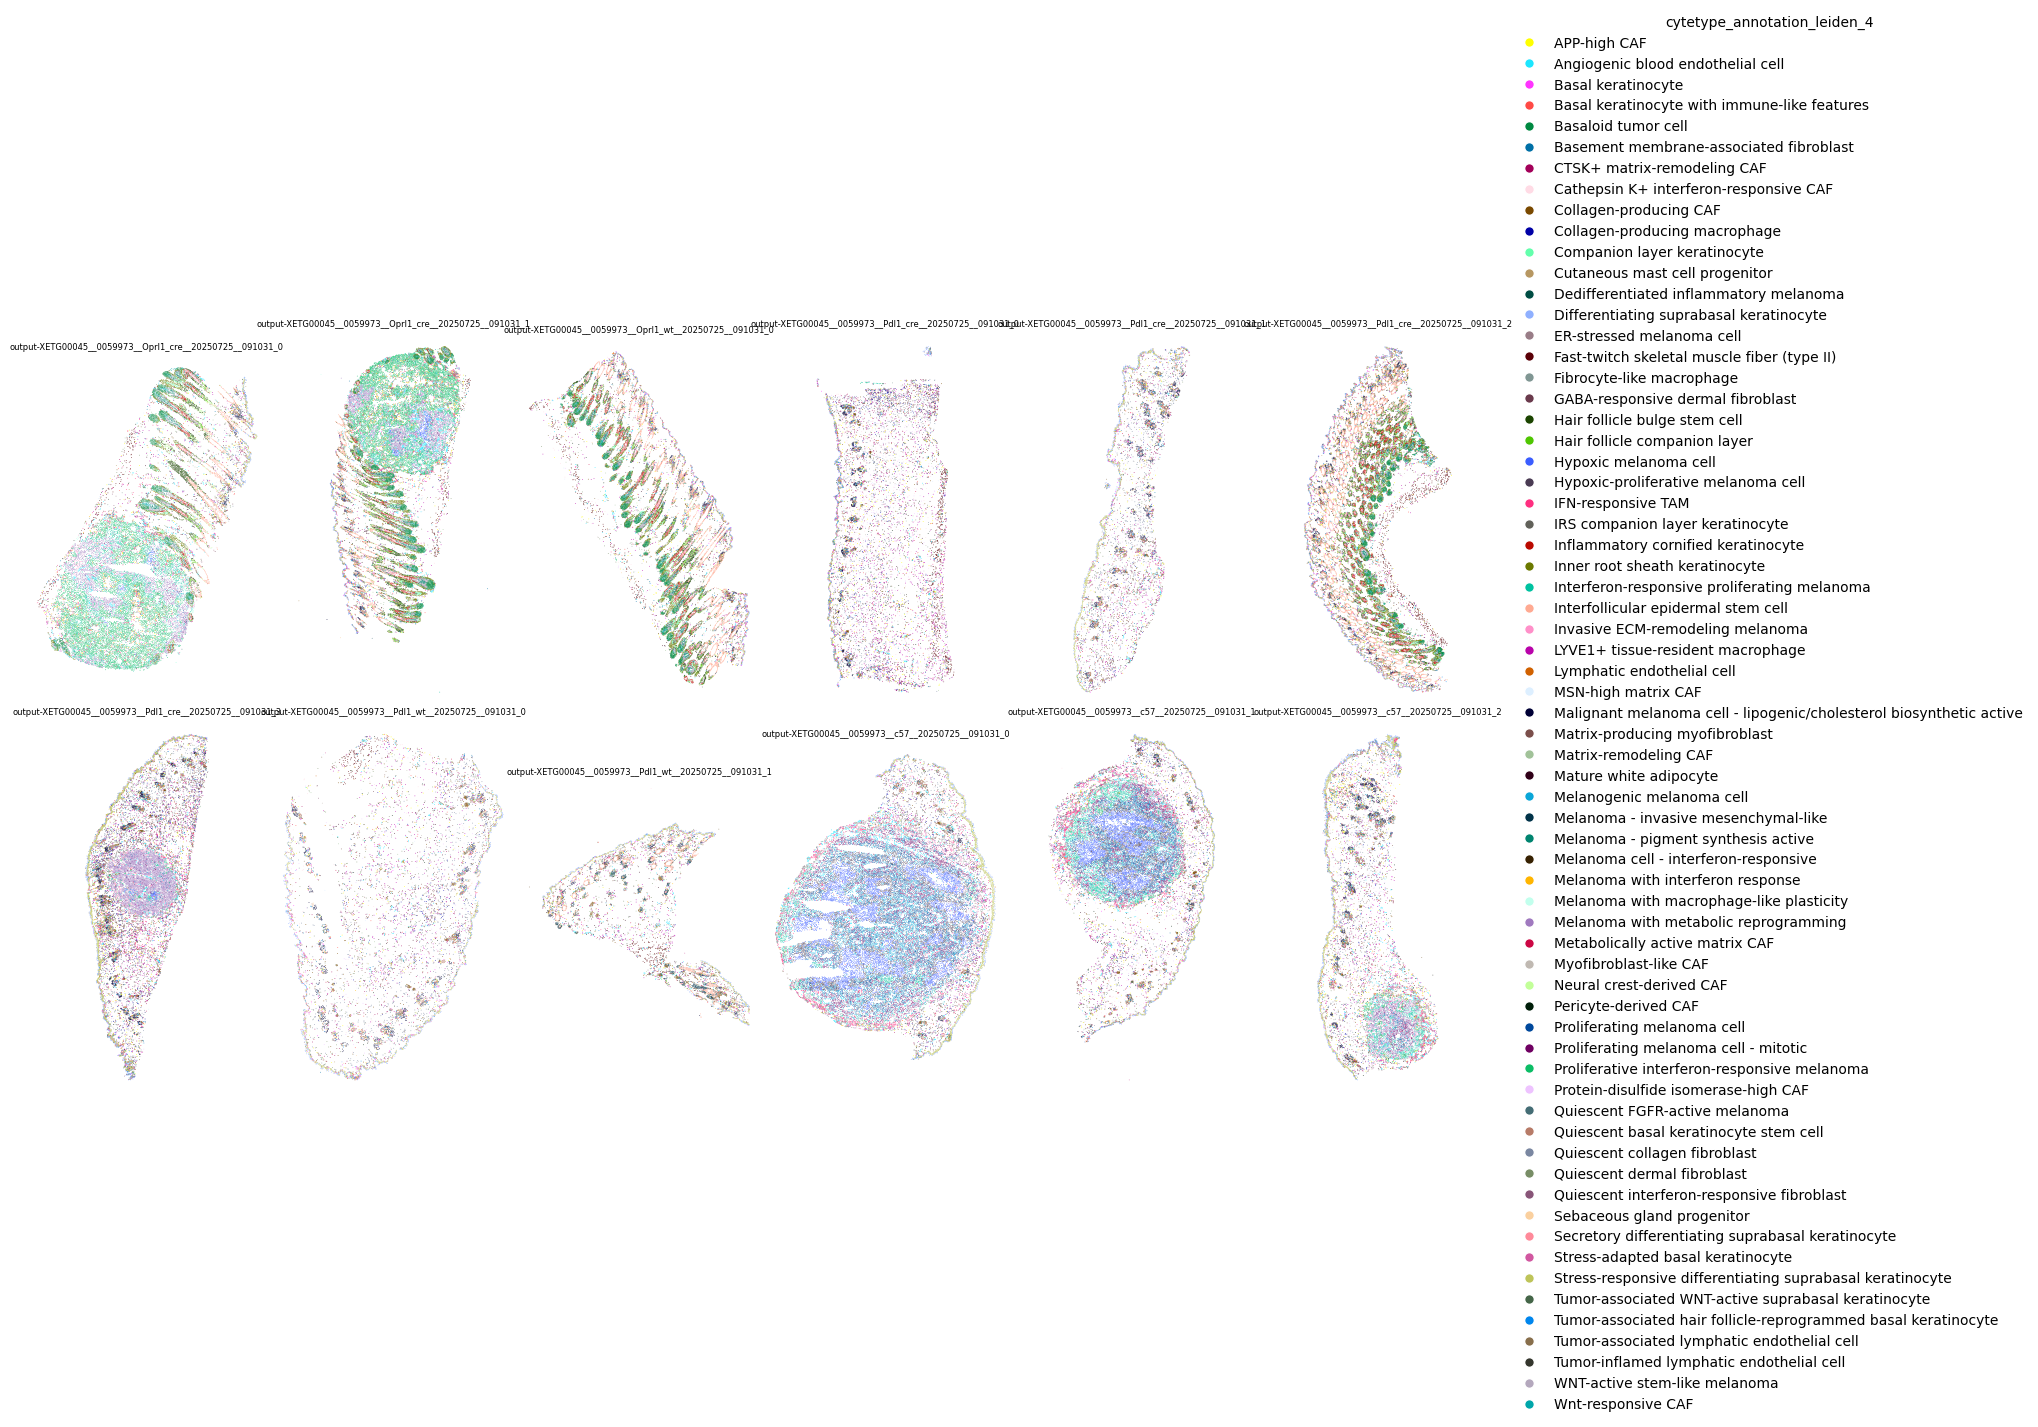

In [36]:
for domain in ['cytetype_annotation_leiden_4']:
    if domain in adata.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata,
            color=domain,
            groupby="sample_id",
            spot_size=0.3,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [37]:
df = adata.obs[["cytetype_annotation_leiden_4", "genotype"]].copy()
df["CellType"] = df["cytetype_annotation_leiden_4"]

counts = (
    df.groupby(["genotype", "CellType"])
      .size()
      .reset_index(name="Count")
)
counts["Proportion"] = (
    counts.groupby(["genotype"])["Count"]
    .transform(lambda x: x / x.sum())
)



In [38]:
import seaborn as sns

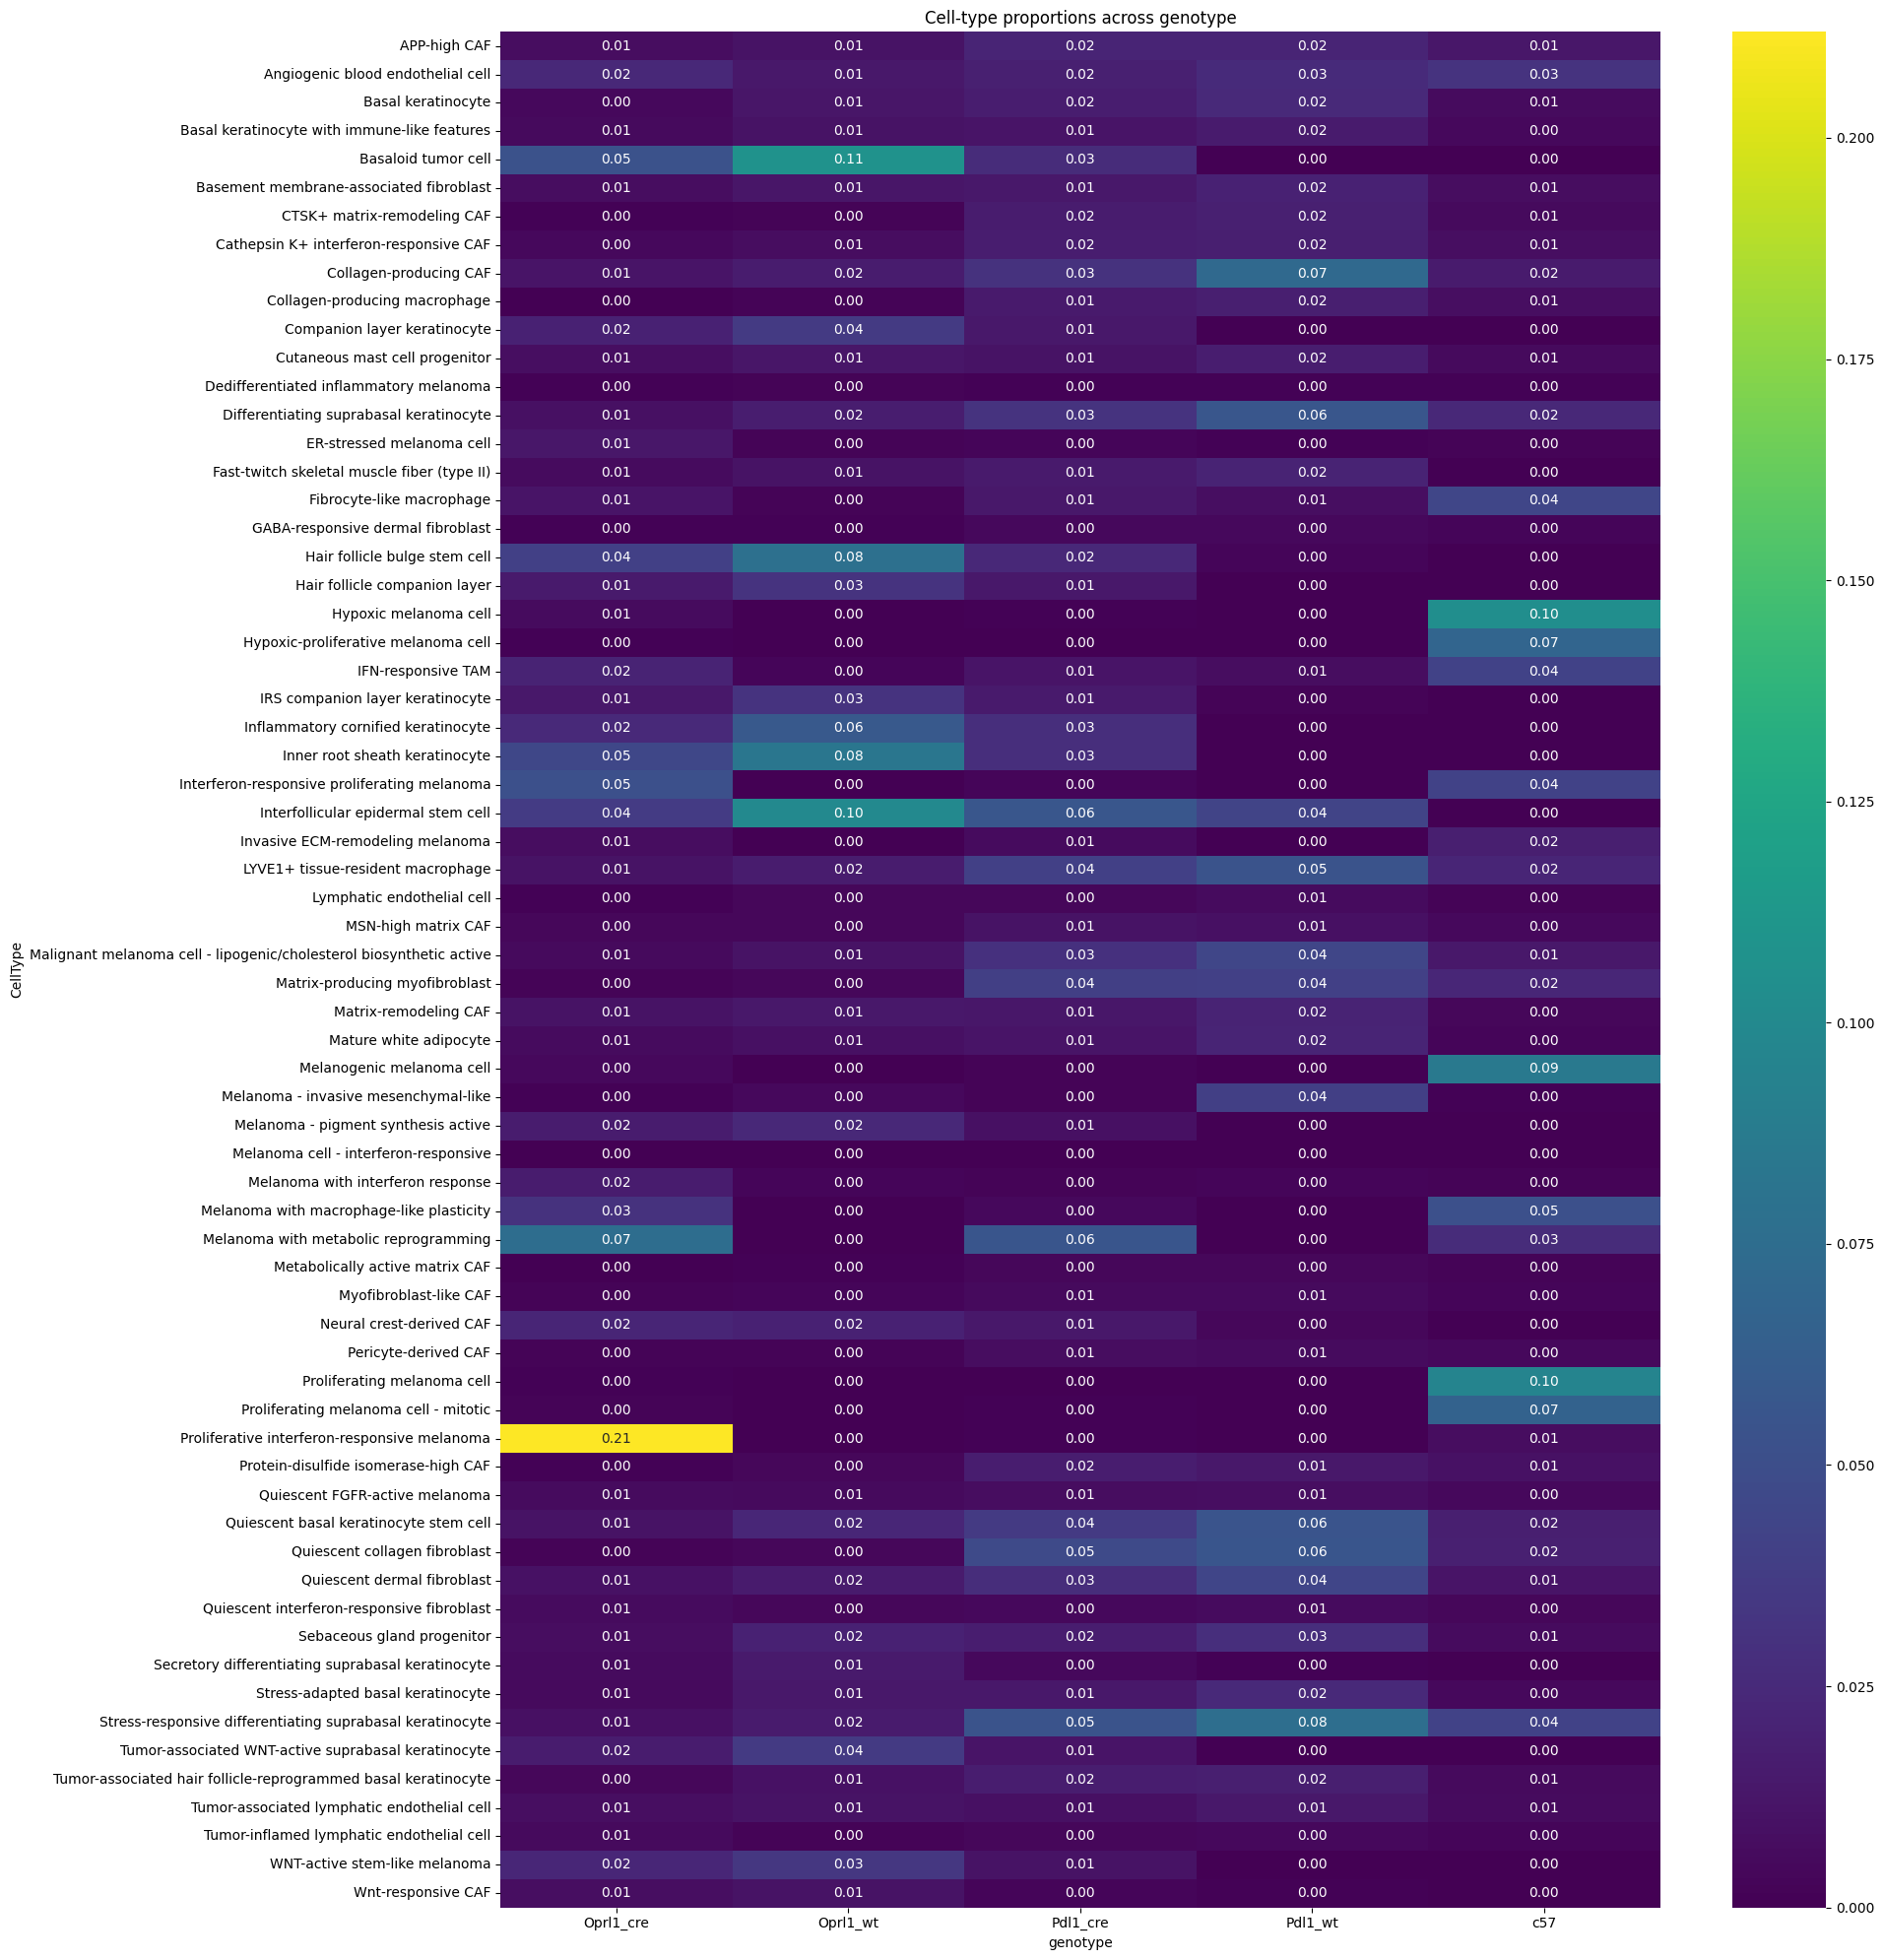

In [39]:
pivot = (
    counts.pivot_table(
        index="CellType", columns=["genotype"],
        values="Proportion", fill_value=0
    )
)

plt.figure(figsize=(20, 20))
sns.heatmap(pivot, cmap="viridis", annot=True, fmt=".2f")
plt.title("Cell-type proportions across genotype")
plt.tight_layout()
plt.show()